# Brownian motion

Een van de bekendste voorbeelden van botsende deeltjes in de natuur is Brownian motion.
Fijn gemalen pollen in water lijken te dansen in willekeurige richting.
Dit komt doordat de pollen worden geraakt door watermoleculen die in alle richtingen bewegen.
Omdat de pollen veel zwaarder zijn dan watermoleculen, dus de beweging van de pollen is veel langzamer en minder "intens" dan die van de watermoleculen.
Dit proces van willekeurige beweging door botsingen met kleinere deeltjes wordt Brownian motion genoemd en kunnen we simuleren op basis van ons (premature) botsingsmodel.
Daarbij kunnen we ook gebruik maken van de zojuist geleerde manier van tracking van deeltjes, waarbij we een zowel het zware bolletjes als een enkel deeltje kunnen volgen.

Let op!
We bestuderen hier nog geen thermische effecten, deze opdrachten zijn met name bedoeld om beter te begrijpen hoe het botsingsmodel in elkaar zit.

```{warning}
In dit notebook zitten delen waar ruimte is om code toe te voegen, maar waarbij je denkt... waarom dan?
In een latere opdracht moet je terug naar die cell en de juiste code toevoegen.
```

In [5]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# Maken van de ParticleClass

class ParticleClass:
    # Het maken van het deeltje
    def __init__(self, m, v, r, R, c):
        self.m = m                         
        self.v = np.array(v, dtype=float)  
        self.r = np.array(r, dtype=float)  
        self.R = np.array(R, dtype=float)  
        self.c = c

    # Het updaten van de positie, eventueel met zwaartekracht
    def update_position(self):
        self.r += self.v * dt #+ 1/2 * a * dt**2  
              
    # Harde wand
    def boxcollision(self):
        if abs(self.r[0]) + self.R > Box_length: 
            self.v[0] = -self.v[0]                                  # Omdraaien van de snelheid
            self.r[0] = np.sign(self.r[0]) * (Box_length - self.R)  # Zet terug net binnen box                 
        if abs(self.r[1]) + self.R > Box_length: 
            self.v[1] = -self.v[1]     
            self.r[1] = np.sign(self.r[1]) * (Box_length - self.R) 
            
    @property
    def momentum(self):
        return self.m * self.v
    
    @property
    def kin_energy(self):
        return 1/2 * self.m * np.dot(self.v, self.v)

In [7]:
# Aanmaken van de randvoorwaarden en initiele condities
Box_size_0 = 10
Box_length_0 = Box_size_0/2
Box_length = Box_length_0     # De grootte van de box kan wijzigen!

# Particles
dt = 0.1
particles = []
N = 40
v_0 = 1

dt = 0.04

# Aanmaken van deeltjes
for i in range(N-1):
    vx = np.random.uniform(-v_0,v_0)
    vy = np.random.choice([-1, 1])*np.sqrt(v_0**2-vx**2)        
    pos = Box_length_0*np.random.uniform(-1,1,2)
    particles.append(ParticleClass(m=1.0, v=[vx, vy], r = pos, R=.5,c='blue')) 

particles.append(ParticleClass(m=20.0, v=[0, 0], r = [0, 0], R=.5,c='red')) 


```{exercise} Brownian motion
:label: ex-brownian-1

Leg uit wat er in de laatste regel van bovenstaande script gebeurt.
Voeg voor deze regel goede metadata toe.
```

```{solution} ex-brownian-1
#your code/answer
```

Er is een doos vol met deeltjes op willekeurige positie aangemaakt.
We willen kijken waar de deeltjes zijn terechtgekomen.
Hieronder staat dit weergegeven. 



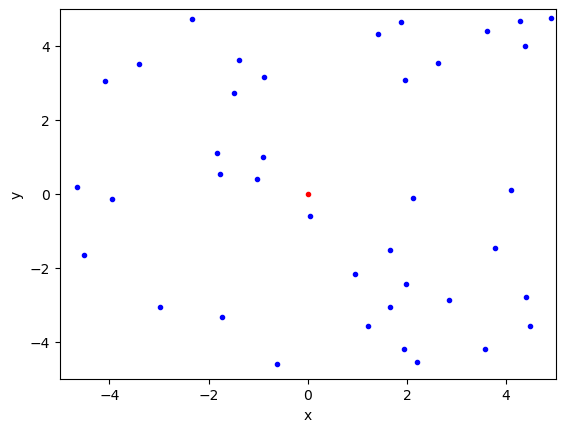

In [8]:
# Inspecteren van beginsituatie
plt.figure()

plt.xlabel('x')
plt.ylabel('y')

plt.xlim(-Box_length_0,Box_length_0)
plt.ylim(-Box_length_0,Box_length_0)


for particle, particle_object in enumerate(particles):
    plt.plot(particle_object.r[0],particle_object.r[1],color=particle_object.c,marker='.')
    # plt.arrow(particle_object.r[0],particle_object.r[1], 
    #           particle_object.v[0],particle_object.v[1], 
    #           head_width=0.05, head_length=0.1, color='red')
plt.show()


```{exercise} 
:label: ex-brownian-2

Er staat ook code met comments ervoor, wat doet deze code? 
Check je antwoord door de comments weg te halen.
Hoe wordt er voor gezorgd dat de snelheid van elk deeltje gelijk is?
```

```{solution} ex-brownian-2
#your code/answer
```

We gaan nu de functies van de simulatie weer aanroepen:

In [9]:
# Het bepalen of er een botsing plaats vindt
def collide_detection(self, other):
    dx = self.r[0] - other.r[0]
    dy = self.r[1] - other.r[1]
    rr = self.R + other.R
    return  dx**2+dy**2 < rr**2 
        
def particle_collision(p1: ParticleClass, p2: ParticleClass):
    """ past snelheden aan uitgaande van overlap """
    m1, m2 = p1.m, p2.m
    delta_r = p1.r - p2.r
    delta_v = p1.v - p2.v
    dot_product = np.dot(delta_r, delta_v)
    
    # Als deeltjes van elkaar weg bewegen dan geen botsing
    if dot_product >= 0: # '='-teken voorkomt ook problemen als delta_r == \vec{0}
        return
    
    distance_squared = np.dot(delta_r, delta_r) 
    # Botsing oplossen volgens elastische botsing in 2D
    p1.v -= 2 * m2 / (m1 + m2) * dot_product / distance_squared * delta_r
    p2.v += 2 * m1 / (m1 + m2) * dot_product / distance_squared * delta_r

def handle_collisions(particles):
#your code/answer
    """ alle onderlinge botsingen afhandelen voor deeltjes in lijst """
    num_particles = len(particles)
    for i in range(num_particles):
        for j in range(i+1, num_particles):
            if collide_detection(particles[i], particles[j]):
                particle_collision(particles[i], particles[j])
#your code/answer


In onderstaande code geven we de code voor de simulatie en volgen we de positie van het zware deeltje. 

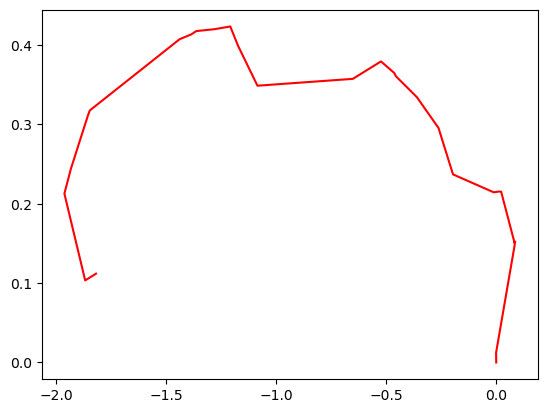

In [10]:
# tracken van het zware deeltje
track_x = []
track_y = []

#your code/answer

#your code/answer

#your code/answer

for i in range(400):
#your code/answer
    
    for p in particles:
        p.update_position()    # Update positie        
        p.boxcollision()         # Wandbotsing werkt per deeltje
        
    handle_collisions(particles)

#your code/answer
    
    track_x.append(particles[N-1].r[0])
    track_y.append(particles[N-1].r[1])
    
#your code/answer

plt.figure()
plt.plot(track_x,track_y,'r')
#your code/answer
plt.show()

```{exercise} Brownian motion in beeld
:label: ex-brownian-3
- Draai de onderstaande simulatie een keer en bestudeer de output.
- Voeg zelf een tweede tracking toe van een licht deeltje en verbeter de plot.
- Wat zijn overeenkomsten en verschillen tussen de beweging van de twee deeltjes?
- Wat valt je op als je de simulatie een aantal keer runt?
```

```{solution} ex-brownian-3
#your code/answer



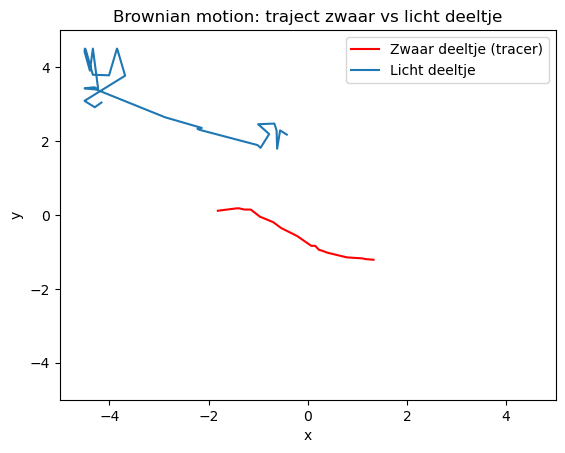

In [14]:


# Tweede tracking + verbeterde plot + observaties (ex-brownian-3)

import numpy as np
import matplotlib.pyplot as plt

# tracken van het zware deeltje (laatste deeltje: index N-1)
track_x_heavy = []
track_y_heavy = []

# tracken van een licht deeltje (bijv. index 0)
light_index = 0
track_x_light = []
track_y_light = []

steps = 400

for i in range(steps):
    # update posities + wandbotsingen
    for p in particles:
        p.update_position()
        p.boxcollision()

    # onderlinge botsingen
    handle_collisions(particles)

    # posities opslaan
    track_x_heavy.append(particles[N-1].r[0])
    track_y_heavy.append(particles[N-1].r[1])

    track_x_light.append(particles[light_index].r[0])
    track_y_light.append(particles[light_index].r[1])

# plot trajecten
plt.figure()
plt.plot(track_x_heavy, track_y_heavy, 'r', label='Zwaar deeltje (tracer)')
plt.plot(track_x_light, track_y_light, label='Licht deeltje')
plt.xlim(-Box_length, Box_length)
plt.ylim(-Box_length, Box_length)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Brownian motion: traject zwaar vs licht deeltje')
plt.legend()
plt.show()

# Antwoorden (kort):
# Overeenkomsten:
# - Beide deeltjes veranderen willekeurig van richting door botsingen.
# - Beide paden zijn onregelmatig en "zigzaggen" door de box.
#
# Verschillen:
# - Het lichte deeltje beweegt veel sneller en maakt grote sprongen per tijdstap.
# - Het zware deeltje beweegt trager: kleine stapjes en meer "drift" (Brownian-achtig).
#
# Meerdere runs:
# - Elke keer krijg je een ander traject, omdat begincondities (posities/snelheden) random zijn
#   en het botsproces chaotisch is (kleine verschillen -> andere botsvolgorde -> ander pad).

We zouden gevoel willen krijgen voor het aantal botsingen dat per tijdseenheid plaatsvindt. 
Elke keer dat er een botsing plaatsvindt, zou de counter met 1 omhoog moeten gaan.
Idealiter wordt het aantal botsingen opgeslagen in een array zodat je het aantal botsingen als functie van de tijd kunt weergeven.

```{exercise}
Pas bovenstaand idee toe in de eerder gemaakte code.
Plot hieronder het aantal botsingen als functie van de tijd.
```

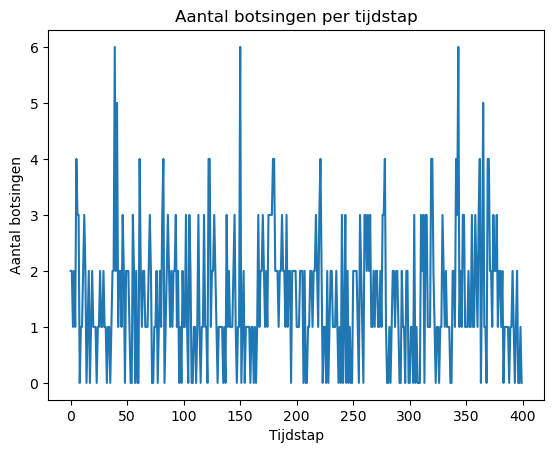

In [15]:
# Botsingen tellen als functie van de tijd

import numpy as np
import matplotlib.pyplot as plt

# Zorg dat handle_collisions(particles) het aantal botsingen retourneert
# (zie definitie hieronder)

def handle_collisions(particles):
    """Alle onderlinge botsingen afhandelen en aantal botsingen tellen."""
    num_particles = len(particles)
    n_collisions = 0
    for i in range(num_particles):
        for j in range(i + 1, num_particles):
            if collide_detection(particles[i], particles[j]):
                particle_collision(particles[i], particles[j])
                n_collisions += 1
    return n_collisions


# simulatie-instellingen
steps = 400
collisions_per_step = []

# simulatie-loop
for i in range(steps):
    # update posities en wandbotsingen
    for p in particles:
        p.update_position()
        p.boxcollision()

    # onderlinge botsingen + tellen
    ncol = handle_collisions(particles)
    collisions_per_step.append(ncol)

# plotten
plt.figure()
plt.plot(np.arange(steps), collisions_per_step)
plt.xlabel("Tijdstap")
plt.ylabel("Aantal botsingen")
plt.title("Aantal botsingen per tijdstap")
plt.show()


```{warning} 🌶 Let op!
:icon: false
De onderstaande opdrachten vallen buiten de stof maar tellen mee als je excellent wilt behalen.
```

In zulke fysica modellen is de afgelegde weg (afstand tussen begin en eindpunt) van belang.
Deze afgelegde weg zegt iets over de snelheid van difussie.
Idealiter bekijken we een histogram.
Maar voor een histogram hebben we veel deeltjes nodig.



```{exercise} Afgelegde weg 🌶
:label: ex-brownian-4

- Maak een simulatie met 361 deeltjes, waarvan 1 zwaar deeltje.
- Houd rekening met de boxgrootte, deze moet mee schalen!
- Maak een histogram van de afgelegde weg voor alle deeltjes. 
- Geef de afgelegde weg van het grote deeltje duidelijk aan.
```


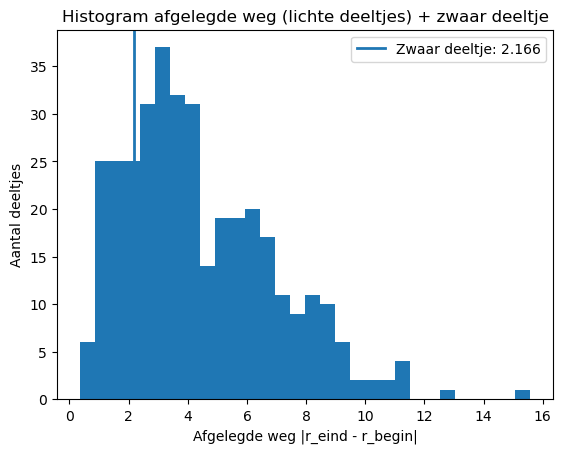

In [17]:
# ex-brownian-4 — Afgelegde weg (361 deeltjes, 1 zwaar) + box schalen + histogram

import numpy as np
import matplotlib.pyplot as plt

# ---- instellingen (pas aan als jouw notebook andere startwaarden gebruikt) ----
N_old = 40          # oorspronkelijk aantal deeltjes in je basisopgave
Box_size_old = 10   # oorspronkelijke boxgrootte
N = 361
v_0 = 1.0
dt = 0.04

# ---- box schalen voor gelijke dichtheid: lengte ~ sqrt(N) ----
scale = np.sqrt(N / N_old)
Box_size_0 = Box_size_old * scale
Box_length_0 = Box_size_0 / 2
Box_length = Box_length_0

# ---- deeltjes maken ----
particles = []

# 360 lichte deeltjes
for i in range(N - 1):
    vx = np.random.uniform(-v_0, v_0)
    vy = np.random.choice([-1, 1]) * np.sqrt(v_0**2 - vx**2)
    pos = Box_length_0 * np.random.uniform(-1, 1, 2)
    particles.append(ParticleClass(m=1.0, v=[vx, vy], r=pos, R=0.5, c='blue'))

# 1 zwaar deeltje (tracer)
particles.append(ParticleClass(m=20.0, v=[0, 0], r=[0, 0], R=0.5, c='red'))

# ---- beginposities opslaan ----
start_pos = np.array([p.r.copy() for p in particles])

# ---- simulatie draaien ----
steps = 600
for _ in range(steps):
    for p in particles:
        p.update_position()
        p.boxcollision()
    handle_collisions(particles)

# ---- eindposities en afgelegde weg (verplaatsing: |r_eind - r_begin|) ----
end_pos = np.array([p.r.copy() for p in particles])
displacements = np.linalg.norm(end_pos - start_pos, axis=1)

heavy_disp = displacements[-1]      # zware deeltje is als laatste toegevoegd
light_disps = displacements[:-1]    # alle lichte deeltjes

# ---- histogram + markering heavy ----
plt.figure()
plt.hist(light_disps, bins=30)
plt.axvline(heavy_disp, linewidth=2, label=f'Zwaar deeltje: {heavy_disp:.3f}')
plt.xlabel('Afgelegde weg |r_eind - r_begin|')
plt.ylabel('Aantal deeltjes')
plt.title('Histogram afgelegde weg (lichte deeltjes) + zwaar deeltje')
plt.legend()
plt.show()


En nu we toch bezig zijn met twee verschillende deeltjes.... 

We kunnen twee "groepen" van deeltjes aanmaken, elk  met een andere massa. Als we dan de zwaartekracht aan zetten, dan zouden we verwachten dat de lichtere deeltjes boven komen "drijven".

```{exercise} Onderzoek dit vermoeden 🌶
- maak daartoe de box 2x zo hoog als breed
- verdubbel het totaal aantal deeltjes
- zet een artificieel grote zwaartekracht aan
```

Gemiddelde y (licht): -3.697274560092809
Gemiddelde y (zwaar): -8.28718664596512


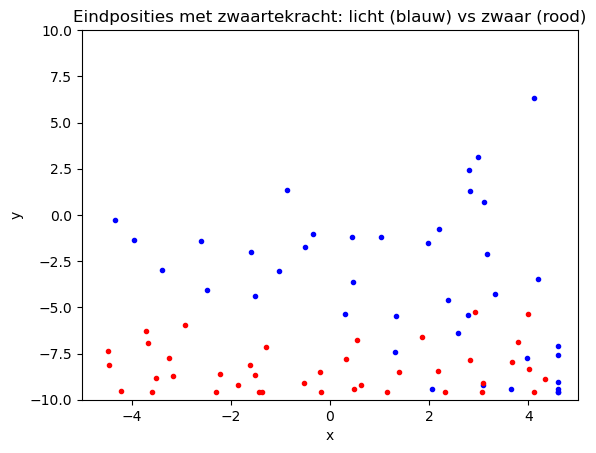

In [18]:
# 🌶 Onderzoek "drijven" met 2 massagroepen + zwaartekracht
# - box 2x zo hoog als breed
# - totaal aantal deeltjes verdubbelen
# - artificieel grote zwaartekracht aan

import numpy as np
import matplotlib.pyplot as plt

# ---------- instellingen ----------
W = 10.0                  # breedte
Box_length_x = W / 2      # half-breedte
Box_length_y = (2*W) / 2  # half-hoogte (dus hoogte = 2*W)

dt = 0.04
v_0 = 1.0
g = 30.0                  # artificieel grote zwaartekracht (omlaag)

N = 80                    # verdubbeld t.o.v. 40
N_light = N // 2
N_heavy = N - N_light

# ---------- ParticleClass voor rechthoekige box + zwaartekracht ----------
class ParticleClass:
    def __init__(self, m, v, r, R, c):
        self.m = float(m)
        self.v = np.array(v, dtype=float)
        self.r = np.array(r, dtype=float)
        self.R = float(R)
        self.c = c

    def update_position(self):
        # zwaartekracht omlaag in y
        self.v[1] -= g * dt
        self.r += self.v * dt

    def boxcollision(self):
        # botsing met verticale wanden
        if abs(self.r[0]) + self.R > Box_length_x:
            self.v[0] *= -1
            self.r[0] = np.sign(self.r[0]) * (Box_length_x - self.R)
        # botsing met horizontale wanden
        if abs(self.r[1]) + self.R > Box_length_y:
            self.v[1] *= -1
            self.r[1] = np.sign(self.r[1]) * (Box_length_y - self.R)

    @property
    def momentum(self):
        return self.m * self.v


# ---------- collide / collision (gebruik jouw bestaande als je die al hebt) ----------
def collide_detection(p1, p2):
    dr = p1.r - p2.r
    rr = p1.R + p2.R
    return np.dot(dr, dr) < rr**2

def particle_collision(p1, p2):
    m1, m2 = p1.m, p2.m
    delta_r = p1.r - p2.r
    delta_v = p1.v - p2.v
    dot_product = np.dot(delta_r, delta_v)

    if dot_product >= 0:
        return

    dist2 = np.dot(delta_r, delta_r)
    if dist2 == 0:
        return

    p1.v -= 2 * m2 / (m1 + m2) * dot_product / dist2 * delta_r
    p2.v += 2 * m1 / (m1 + m2) * dot_product / dist2 * delta_r

def handle_collisions(particles):
    n = len(particles)
    for i in range(n):
        for j in range(i + 1, n):
            if collide_detection(particles[i], particles[j]):
                particle_collision(particles[i], particles[j])

# ---------- deeltjes maken: 2 groepen ----------
particles = []

# lichte groep (blauw)
for _ in range(N_light):
    vx = np.random.uniform(-v_0, v_0)
    vy = np.random.choice([-1, 1]) * np.sqrt(v_0**2 - vx**2)
    pos = np.array([Box_length_x, Box_length_y]) * np.random.uniform(-1, 1, 2)
    particles.append(ParticleClass(m=1.0, v=[vx, vy], r=pos, R=0.4, c='blue'))

# zware groep (rood)
for _ in range(N_heavy):
    vx = np.random.uniform(-v_0, v_0)
    vy = np.random.choice([-1, 1]) * np.sqrt(v_0**2 - vx**2)
    pos = np.array([Box_length_x, Box_length_y]) * np.random.uniform(-1, 1, 2)
    particles.append(ParticleClass(m=5.0, v=[vx, vy], r=pos, R=0.4, c='red'))

# ---------- simulatie ----------
steps = 800
for _ in range(steps):
    for p in particles:
        p.update_position()
        p.boxcollision()
    handle_collisions(particles)

# ---------- analyse: gemiddelde hoogte per groep ----------
ys_light = [p.r[1] for p in particles[:N_light]]
ys_heavy = [p.r[1] for p in particles[N_light:]]

print("Gemiddelde y (licht):", np.mean(ys_light))
print("Gemiddelde y (zwaar):", np.mean(ys_heavy))

# ---------- plot eindposities ----------
plt.figure()
for p in particles:
    plt.plot(p.r[0], p.r[1], marker='.', color=p.c, linestyle='None')
plt.xlim(-Box_length_x, Box_length_x)
plt.ylim(-Box_length_y, Box_length_y)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Eindposities met zwaartekracht: licht (blauw) vs zwaar (rood)')
plt.show()

# Korte conclusie (wat je meestal ziet):
# - Zonder echte "opwaartse kracht" (Archimedes/medium) zakt alles naar beneden door zwaartekracht.
# - Wel kan er een verschil in verdeling ontstaan door botsingen: zware deeltjes zitten gemiddeld lager.

